In [1]:
import numpy as np
import xarray as xr
import cf_xarray as cfxr
import cf_xarray.units
import pint_xarray
import pint
from pint import application_registry as ureg
import matplotlib.pyplot as plt
import intake
import seaborn as sns, matplotlib.pyplot as plt
from os import environ
import cmocean as cm
environ["PYTHONWARNINGS"] = "ignore"

In [2]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

cluster = SLURMCluster(
    memory="100GB",
    processes=8,
    cores=8,
    walltime="02:00:00",
    queue="dcgp_usr_prod",
    account="ICT26_ESP",
    interface="ib0",
    job_extra=[
        "--nodes=1",
        "--ntasks-per-node=8",
        "--hint=nomultithread"
    ],
    job_script_prologue=[
    "source ~/.venvs/ocean2/bin/activate",
    "export HDF5_USE_FILE_LOCKING=FALSE",
    "export OMP_NUM_THREADS=1",
    "export MKL_NUM_THREADS=1",
    "export NUMBA_NUM_THREADS=1"
    ],   
    log_directory="logs/"
)

cluster.scale(16)
client = Client(cluster)

/leonardo/home/userexternal/ntilinin/.venvs/ocean2/lib/python3.11/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/leonardo/home/userexternal/ntilinin/.venvs/ocean2/lib/python3.11/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWar

In [24]:
%%time 

experiment = 'AccessOm2IAF'

CPU times: user 8 μs, sys: 5 μs, total: 13 μs
Wall time: 23.6 μs


In [4]:
%%time 
CATALOG_sp = "/leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2-catalog/AccessOm2IAF_SPEEDY.json"

catalog_sp = intake.open_esm_datastore(
    CATALOG_sp,
    columns_with_iterables=[
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units",
    ]
)

CATALOG_jr = "/leonardo_scratch/fast/ICT26_ESP/ntilinin/access-om2-catalog/AccessOm2IAF_JRA55.json"

catalog_jr = intake.open_esm_datastore(
    CATALOG_jr,
    columns_with_iterables=[
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units",
    ]
)

CPU times: user 18.4 s, sys: 1.37 s, total: 19.8 s
Wall time: 22.5 s


In [13]:
for v in ["ty_trans_rho", "ty_trans_rho_gm", "pot_rho_2"]:
    print(v, len(catalog_sp.search(variable=v).df), len(catalog_jr.search(variable=v).df))

ty_trans_rho 62 62
ty_trans_rho_gm 62 62
pot_rho_2 62 62


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def overturning_ts(cat):
    ds = cat.search(
        variable=["ty_trans_rho","ty_trans_rho_gm"],
        frequency="1mon"
    ).to_dask(
        xarray_open_kwargs={
            "engine":"h5netcdf",
            "chunks":{"potrho":-1}
        }
    ).sel(time=slice("1958-01-01","2019-12-31"))

    r = ds.ty_trans_rho
    gm = ds.ty_trans_rho_gm

    r40 = r.sum("grid_xt_ocean").sel(grid_yu_ocean=-40,method="nearest")*1e-9
    gm40 = gm.sum("grid_xt_ocean").sel(grid_yu_ocean=-40,method="nearest")*1e-9
    psi40 = r40.cumsum("potrho") - r40.sum("potrho") + gm40
    aabw = -psi40.sel(potrho=slice(1036,None)).min("potrho").resample(time="YE").mean()

    r26 = r.sel(grid_xt_ocean=slice(-103,-5)).sum("grid_xt_ocean").sel(grid_yu_ocean=26,method="nearest")*1e-9
    gm26 = gm.sel(grid_xt_ocean=slice(-103,-5)).sum("grid_xt_ocean").sel(grid_yu_ocean=26,method="nearest")*1e-9
    psi26 = r26.cumsum("potrho") - r26.sum("potrho") + gm26
    amoc = psi26.sel(potrho=slice(1035.5,None)).max("potrho").resample(time="YE").mean()

    return amoc.compute(), aabw.compute()

amoc_jr, aabw_jr = overturning_ts(catalog_jr)
amoc_sp, aabw_sp = overturning_ts(catalog_sp)

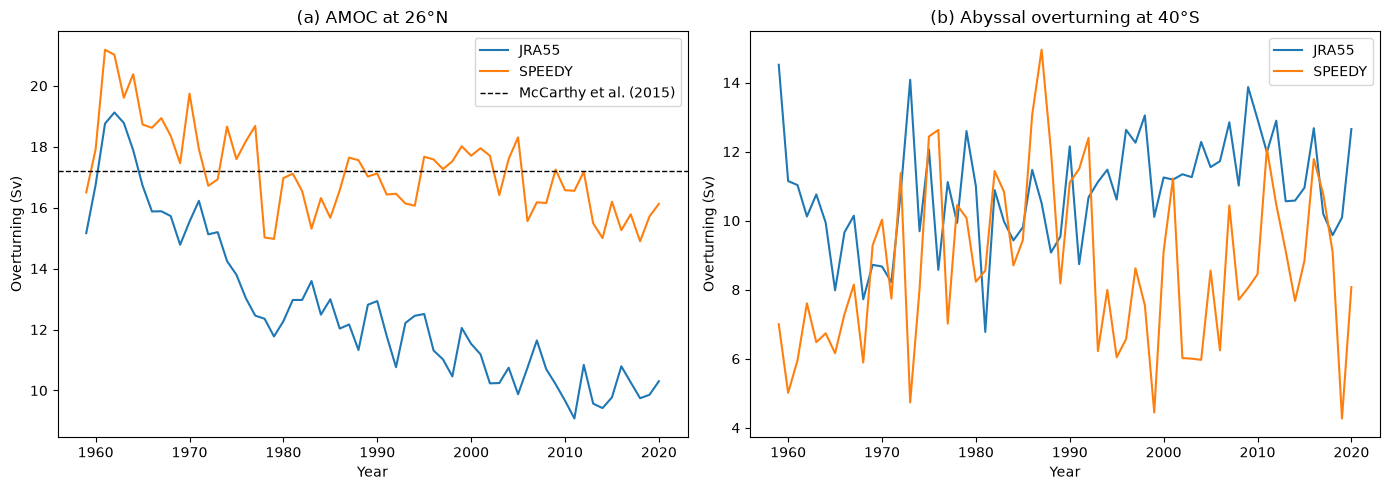

In [7]:
fig,axs = plt.subplots(1,2,figsize=(14,5))

axs[0].plot(amoc_jr.time,amoc_jr,label="JRA55")
axs[0].plot(amoc_sp.time,amoc_sp,label="SPEEDY")
axs[0].axhline(17.2,color="k",ls="--",lw=1,label="McCarthy et al. (2015)")
axs[0].set_title("(a) AMOC at 26°N")
axs[0].set_xlabel("Year")
axs[0].set_ylabel("Overturning (Sv)")
axs[0].legend()

axs[1].plot(aabw_jr.time,aabw_jr,label="JRA55")
axs[1].plot(aabw_sp.time,aabw_sp,label="SPEEDY")
axs[1].set_title("(b) Abyssal overturning at 40°S")
axs[1].set_xlabel("Year")
axs[1].set_ylabel("Overturning (Sv)")
axs[1].legend()

plt.tight_layout()
plt.savefig("figures/access_om2_amoc_AO_IAF.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [9]:
print("AMOC JRA55 :",float(amoc_jr.mean()))
print("AMOC SPEEDY:",float(amoc_sp.mean()))
print("AABW JRA55 :",float(aabw_jr.mean()))
print("AABW SPEEDY:",float(aabw_sp.mean()))

AMOC JRA55 : 12.65748405456543
AMOC SPEEDY: 17.187942504882812
AABW JRA55 : 10.843035697937012
AABW SPEEDY: 8.675847053527832


In [13]:
def gmoc(cat):
    ds = cat.search(
        variable=["ty_trans_rho","ty_trans_rho_gm"],
        frequency="1mon"
    ).to_dask(
        xarray_open_kwargs={
            "engine":"h5netcdf",
            "chunks":{"potrho":-1}
        }
    ).sel(time=slice("1993-01-01","2017-12-31"))

    r = ds.ty_trans_rho/(1035*1e6)
    gm = ds.ty_trans_rho_gm/(1035*1e6)

    r = r.sum("grid_xt_ocean")
    gm = gm.sum("grid_xt_ocean")

    psi = r.cumsum("potrho") - r.sum("potrho") + gm
    psi = psi.mean("time")

    return psi.compute()

In [14]:
print("SPEEDY")
sp = gmoc(catalog_sp)
print("JRA55")
jr = gmoc(catalog_jr)
df = sp-jr

SPEEDY


JRA55


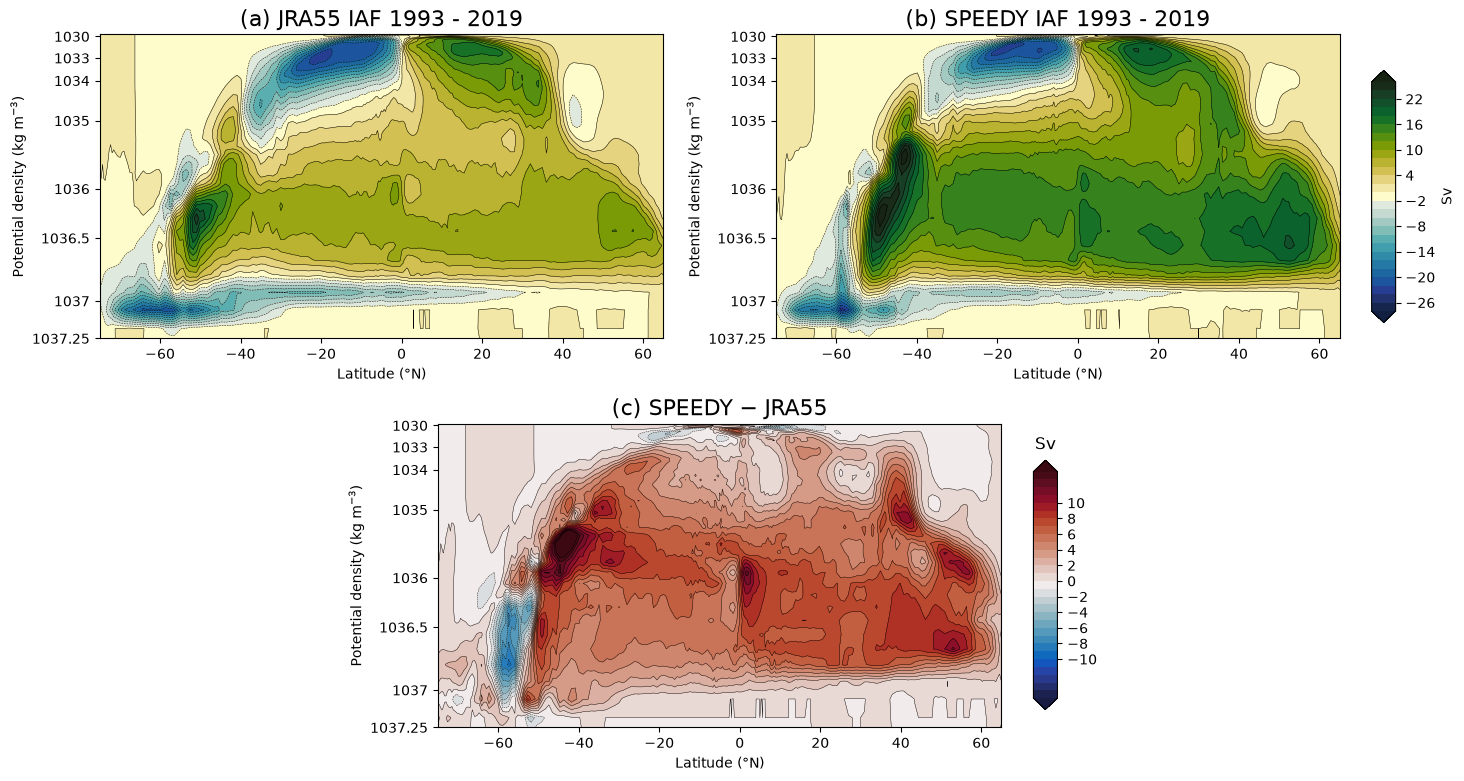

In [15]:
rho_max = 1037.25
dens0 = 1020

def ycoord(rho):
    return (np.asarray(rho)-dens0)**9

def prep(x):
    return x.assign_coords(potrho=("potrho",ycoord(x.potrho.values)))

jr_p = prep(jr)
sp_p = prep(sp)
df_p = prep(sp-jr)

rho_top = min(float(jr.potrho.min()),float(sp.potrho.min()))
rho_bottom = max(float(jr.potrho.max()),float(sp.potrho.max()))

ticklabels = np.array([1030,1033,1034,1035,1036,1036.5,1037,1037.25])
ticks = ycoord(ticklabels)

lev = np.arange(-28, 28, 2)
dlev = np.arange(-15, 15, 1)

fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 4, hspace=.28, wspace=.5)

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 1:3])

for ax, x, title in [
    (ax1, jr_p, "(a) JRA55 IAF 1993 - 2019"),
    (ax2, sp_p, "(b) SPEEDY IAF 1993 - 2019"),
]:
    cf = ax.contourf(
        x.grid_yu_ocean, x.potrho, x,
        levels=lev, cmap=cm.cm.delta, extend="both"
    )
    ax.contour(
        x.grid_yu_ocean, x.potrho, x,
        levels=lev, colors="k", linewidths=.35
    )
    ax.set_xlim(-75, 65)
    #ax.set_ylim(ycoord(rho_bottom),ycoord(rho_top))
    ax.set_ylim(ycoord(1037.25),ycoord(rho_top))
    #ax.set_ylim(ycoord(rho_max), ycoord(float(x.potrho.min()**(1/9) + dens0)) if False else ycoord(float(jr.potrho.min())))
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{v:g}" for v in ticklabels])
    ax.set_xlabel("Latitude (°N)")
    ax.set_ylabel("Potential density (kg m$^{-3}$)")
    ax.set_title(title, fontsize=16)
    
cdf = ax3.contourf(
    df_p.grid_yu_ocean, df_p.potrho, df_p,
    levels=dlev, cmap=cm.cm.balance, extend="both"
)
ax3.contour(
    df_p.grid_yu_ocean, df_p.potrho, df_p,
    levels=dlev, colors="k", linewidths=.3
)
ax3.set_xlim(-75, 65)
#ax3.set_ylim(ycoord(rho_max), ycoord(float(jr.potrho.min())))
ax3.set_ylim(ycoord(1037.25),ycoord(rho_top))
#ax3.set_ylim(ycoord(rho_bottom),ycoord(rho_top))
ax3.set_yticks(ticks)
ax3.set_yticklabels([f"{v:g}" for v in ticklabels])
ax3.set_xlabel("Latitude (°N)")
ax3.set_ylabel("Potential density (kg m$^{-3}$)")
ax3.set_title("(c) SPEEDY − JRA55", fontsize=16)

cax1 = fig.add_axes([.92, .56, .015, .28])
cb1 = fig.colorbar(cf, cax=cax1, ticks=np.arange(-26, 26, 6))
cb1.set_label("Sv")

pos3 = ax3.get_position()
cax2 = fig.add_axes([pos3.x1 + 0.02, pos3.y0 + 0.02, 0.015, pos3.height * 0.82])
cb2 = fig.colorbar(cdf, cax=cax2, ticks=np.arange(-10,11,2))
cb2.ax.set_title("Sv", pad=8)
plt.savefig("figures/access_om2_GMOC_density_IAF.png",
            dpi=300, bbox_inches="tight")
plt.show()

In [16]:
print("JRA:", float(jr.min()), float(jr.max()))
print("SPEEDY:", float(sp.min()), float(sp.max()))
print("DIFF:", float((sp-jr).min()), float((sp-jr).max()))

JRA: -23.189889907836914 23.62225914001465
SPEEDY: -25.124435424804688 27.58800506591797
DIFF: -9.315685272216797 21.071083068847656


In [90]:
import xarray as xr
import numpy as np

def gmoc_parts(cat):
    ds = cat.search(
        variable=["ty_trans_rho","ty_trans_rho_gm"],
        frequency="1mon"
    ).to_dask(
        xarray_open_kwargs={
            "engine":"h5netcdf",
            "chunks":{"potrho":-1}
        }
    ).sel(time=slice("1958-01-01","2019-12-31"))

    r = ds.ty_trans_rho/(1035*1e6)
    gm = ds.ty_trans_rho_gm/(1035*1e6)

    r = r.sum("grid_xt_ocean")
    gm = gm.sum("grid_xt_ocean")

    resolved = r.cumsum("potrho") - r.sum("potrho")
    total = resolved + gm

    return xr.Dataset({
        "resolved": resolved.mean("time"),
        "gm": gm.mean("time"),
        "total": total.mean("time")
    }).compute()

parts_jr = gmoc_parts(catalog_jr)
parts_sp = gmoc_parts(catalog_sp)

diff = parts_sp - parts_jr

for v in ["resolved","gm","total"]:
    print(v,
          "JRA", float(parts_jr[v].min()), float(parts_jr[v].max()),
          "SPEEDY", float(parts_sp[v].min()), float(parts_sp[v].max()),
          "DIFF", float(diff[v].min()), float(diff[v].max()))

: 

In [ ]:
import matplotlib.pyplot as plt
import cmocean as cm

rho_floor = 1010
rho_break = 1030
rho_max = 1037.25
low_fraction = .25
dense_power = 8

def stretch(v):
    v = np.asarray(v,dtype=float)
    out = np.empty_like(v)
    m = v <= rho_break
    out[m] = low_fraction*(v[m]-rho_floor)/(rho_break-rho_floor)
    out[~m] = low_fraction+(1-low_fraction)*((v[~m]-rho_break)/(rho_max-rho_break))**dense_power
    return out

def prep(x):
    x = x.sel(potrho=slice(None,rho_max))
    return x.assign_coords(potrho=("potrho",stretch(x.potrho.values)))

ticks_lbl = np.array([1030,1033,1034,1035,1036,1036.5,1037,1037.25])
ticks = stretch(ticks_lbl)

fig,axs = plt.subplots(1,3,figsize=(18,5))
levels = np.arange(-20,21,2)

for ax,v,title in zip(
    axs,
    ["resolved","gm","total"],
    ["Resolved","GM","Total"]
):
    x = prep(diff[v])
    cf = ax.contourf(
        x.grid_yu_ocean,x.potrho,x,
        levels=levels,cmap=cm.cm.balance,extend="both"
    )
    ax.contour(
        x.grid_yu_ocean,x.potrho,x,
        levels=levels,colors="k",linewidths=.25
    )
    ax.set_xlim(-75,65)
    ax.set_ylim(stretch(rho_max),stretch(rho_break))
    ax.set_yticks(ticks)
    ax.set_yticklabels([f"{t:g}" for t in ticks_lbl])
    ax.set_xlabel("Latitude (°N)")
    ax.set_title(f"{title}: SPEEDY − JRA55")

axs[0].set_ylabel("Potential density (kg m$^{-3}$)")

cb = fig.colorbar(cf,ax=axs,pad=.025,shrink=.85,ticks=np.arange(-20,21,4))
cb.ax.set_title("Sv",pad=8)

plt.show()

In [17]:
client.close()
cluster.close()

/leonardo/home/userexternal/ntilinin/.venvs/ocean2/lib/python3.11/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
